# 08 · Principal Component Analysis (PCA)

Reduce the feature space using PCA, inspect the **scree plot** and **variance explained**, then visualise the 2-D projection coloured by direction.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))
import config

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid')
np.random.seed(config.RANDOM_STATE)
plt.rcParams.update({'figure.dpi': config.FIG_DPI})

## 1. Load Features

In [ ]:
df = pd.read_csv(
    config.PROCESSED_DATA_CSV,
    index_col='Date', parse_dates=True
)

FEATURES = ['MA_cross', 'Volatility', 'RSI', 'BB_width', 'BB_pct', 'LogReturn']
X = df[FEATURES].values
y = df[config.TARGET_COL].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'Asset: {config.ASSET_NAME} ({config.ASSET_TICKER})')
print(f'Feature matrix shape: {X_scaled.shape}')

Feature matrix shape: (3893, 6)


## 2. Fit PCA (all components)

In [3]:
pca_full = PCA()
pca_full.fit(X_scaled)

explained_var   = pca_full.explained_variance_ratio_
cum_explained   = np.cumsum(explained_var)
n_components    = len(explained_var)

print('Variance explained per component:')
for i, (ev, cev) in enumerate(zip(explained_var, cum_explained), 1):
    print(f'  PC{i}: {ev:.4f}  (cumulative: {cev:.4f})')

Variance explained per component:
  PC1: 0.4591  (cumulative: 0.4591)
  PC2: 0.2037  (cumulative: 0.6628)
  PC3: 0.1633  (cumulative: 0.8261)
  PC4: 0.1256  (cumulative: 0.9517)
  PC5: 0.0303  (cumulative: 0.9820)
  PC6: 0.0180  (cumulative: 1.0000)


## 3. Scree Plot

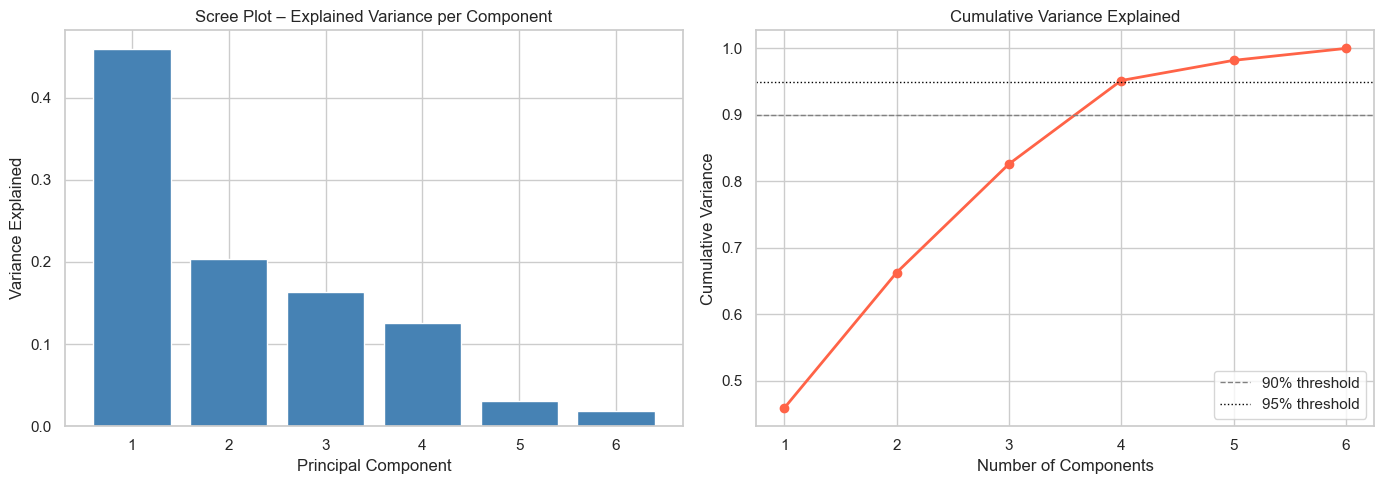

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual
axes[0].bar(range(1, n_components + 1), explained_var,
            color='steelblue', edgecolor='white')
axes[0].set_title('Scree Plot – Explained Variance per Component')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained')
axes[0].set_xticks(range(1, n_components + 1))

# Cumulative
axes[1].plot(range(1, n_components + 1), cum_explained,
             marker='o', color='tomato', linewidth=2)
axes[1].axhline(0.90, color='grey', linestyle='--', linewidth=1, label='90% threshold')
axes[1].axhline(0.95, color='black', linestyle=':', linewidth=1, label='95% threshold')
axes[1].set_title('Cumulative Variance Explained')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance')
axes[1].set_xticks(range(1, n_components + 1))
axes[1].legend()

plt.tight_layout()
plt.show()

- The scree plot shows variance explained by each principal component.
- The cumulative curve shows how many components are needed to retain most information.
- This helps decide dimensionality reduction without losing too much signal.

## 4. 2-D PCA Projection

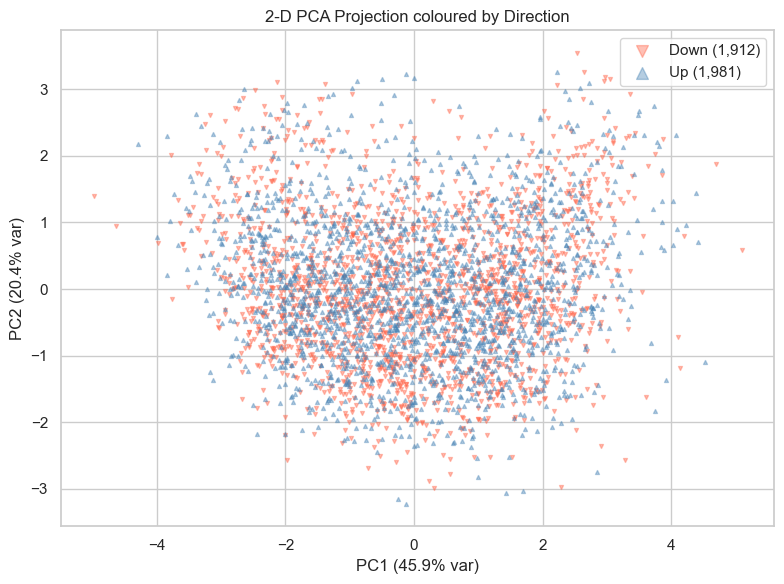

PC1 explains 45.91% of variance
PC2 explains 20.37% of variance


In [5]:
pca2 = PCA(n_components=2, random_state=config.RANDOM_STATE)
X_2d = pca2.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_2d, columns=['PC1', 'PC2'])
df_pca['Direction'] = y

fig, ax = plt.subplots(figsize=(8, 6))
for label, color, marker in [(0, 'tomato', 'v'), (1, 'steelblue', '^')]:
    mask = df_pca['Direction'] == label
    ax.scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
               c=color, s=8, alpha=0.4, marker=marker,
               label=f"{'Up' if label else 'Down'} ({mask.sum():,})")

ax.set_title('2-D PCA Projection coloured by Direction')
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]:.1%} var)')
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

print(f'PC1 explains {pca2.explained_variance_ratio_[0]:.2%} of variance')
print(f'PC2 explains {pca2.explained_variance_ratio_[1]:.2%} of variance')

- This 2D projection visualizes samples in reduced PCA space.
- Clear separation would indicate easier class discrimination.
- Heavy overlap suggests direction classes are hard to separate linearly.

## 5. PCA Loadings (Feature Contributions)

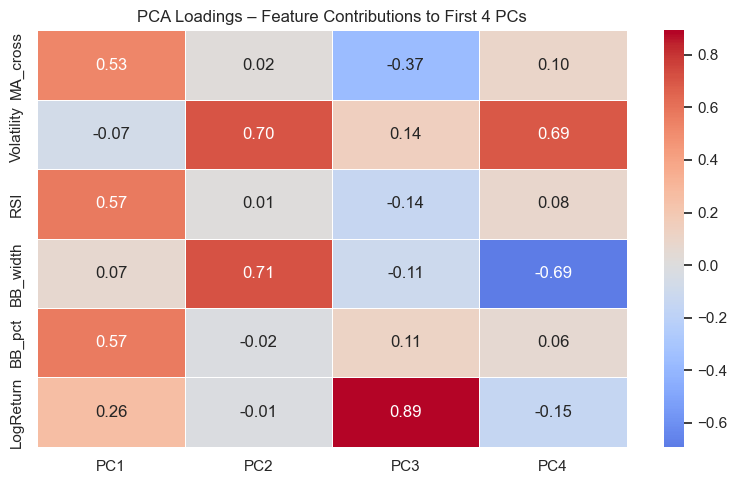

              PC1    PC2    PC3    PC4    PC5    PC6
MA_cross    0.526  0.020 -0.371  0.097  0.684 -0.330
Volatility -0.069  0.704  0.142  0.692  0.012  0.001
RSI         0.573  0.010 -0.142  0.077 -0.147  0.790
BB_width    0.066  0.709 -0.107 -0.692 -0.038 -0.015
BB_pct      0.566 -0.019  0.113  0.063 -0.631 -0.514
LogReturn   0.256 -0.015  0.893 -0.148  0.334  0.052


In [6]:
loadings = pd.DataFrame(
    pca_full.components_.T,
    index=FEATURES,
    columns=[f'PC{i}' for i in range(1, n_components + 1)]
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(loadings.iloc[:, :4], annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, ax=ax)
ax.set_title('PCA Loadings – Feature Contributions to First 4 PCs')
plt.tight_layout()
plt.show()

print(loadings.round(3))

- Loadings show how original features contribute to each principal component.
- Larger absolute values mean stronger contribution.
- This links reduced components back to interpretable original variables.